In [17]:
# =================================================================================
# 📘 train_random_forest_mejorado.ipynb
# Entrenamiento del modelo Random Forest con control de overfitting (<5%)
# =================================================================================

# -----------------------------
# 1️⃣ Importación de librerías
# -----------------------------
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import shuffle

In [18]:
# -----------------------------
# 2️⃣ Cargar embeddings
# -----------------------------
print("🔍 Cargando embeddings desde ../backend/models/embeddings.pkl ...")

emb_path = Path("../backend/models/embeddings.pkl").resolve()
if not emb_path.exists():
    raise FileNotFoundError(f"No se encontró el archivo {emb_path}")

with open(emb_path, "rb") as f:
    data = pickle.load(f)

# Soporte para distintos formatos
if isinstance(data, dict):
    X = data.get("X") or  data.get("embeddings")
    y = data.get("y") or data.get("labels") 
elif isinstance(data, (list, tuple)):
    X, y = data
else:
    raise ValueError("Formato de embeddings.pkl no reconocido")

X, y = np.array(X), np.array(y)
print(f"✅ Embeddings cargados: X={X.shape}, y={y.shape}, Clases={len(np.unique(y))}")


🔍 Cargando embeddings desde ../backend/models/embeddings.pkl ...
✅ Embeddings cargados: X=(20760, 1280), y=(20760,), Clases=21


In [19]:
# -----------------------------
# 3️⃣ Preprocesamiento y reducción PCA
# -----------------------------
print("\n🔧 Estandarizando y reduciendo dimensionalidad con PCA (90% varianza)...")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=0.90, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"✅ PCA aplicado: {X_pca.shape[1]} componentes conservan 90% de la varianza")

# -----------------------------
# 4️⃣ División Train/Test estratificada
# -----------------------------
X_pca, y = shuffle(X_pca, y, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, stratify=y, random_state=42
)
print(f"✅ División de datos -> Train: {X_train.shape}, Test: {X_test.shape}")



🔧 Estandarizando y reduciendo dimensionalidad con PCA (90% varianza)...
✅ PCA aplicado: 658 componentes conservan 90% de la varianza
✅ División de datos -> Train: (16608, 658), Test: (4152, 658)


In [20]:
# -----------------------------
# 5️⃣ Entrenamiento con control de overfitting
# -----------------------------
print("\n🌲 Entrenando Random Forest con control de overfitting...")

# Parámetros más restrictivos
rf_params = {
    "n_estimators": 100,
    "max_depth": 8,
    "min_samples_split": 20,
    "min_samples_leaf": 10,
    "max_features": "sqrt",
    "class_weight": "balanced",
    "random_state": 42,
    "n_jobs": -1,
}


🌲 Entrenando Random Forest con control de overfitting...


In [21]:

# Validación cruzada (3 folds)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

best_diff = float("inf")
best_model = None

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train), 1):
    print(f"\n📦 Fold {fold}/3...")
    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]
    
    model = RandomForestClassifier(**rf_params)
    model.fit(X_tr, y_tr)
    
    train_acc = accuracy_score(y_tr, model.predict(X_tr))
    val_acc = accuracy_score(y_val, model.predict(X_val))
    diff = abs(train_acc - val_acc) * 100

    print(f"   🔹 Train acc: {train_acc*100:.2f}% | Val acc: {val_acc*100:.2f}% | Diff: {diff:.2f}%")

    if diff < best_diff:
        best_diff = diff
        best_model = model



📦 Fold 1/3...
   🔹 Train acc: 76.98% | Val acc: 45.29% | Diff: 31.69%

📦 Fold 2/3...
   🔹 Train acc: 77.19% | Val acc: 44.98% | Diff: 32.21%

📦 Fold 3/3...
   🔹 Train acc: 76.46% | Val acc: 46.08% | Diff: 30.38%


In [22]:
# -----------------------------
# 6️⃣ Evaluación final
# -----------------------------
y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)
diff = abs(train_acc - test_acc) * 100

print("\n📊 Resultados Finales:")
print(f"   Accuracy Entrenamiento: {train_acc*100:.2f}%")
print(f"   Accuracy Validación   : {test_acc*100:.2f}%")
print(f"   Diferencia: {diff:.2f}%")

if diff <= 5:
    print("✅ Overfitting controlado correctamente (<5%)")
else:
    print("⚠️ Overfitting aún alto — considera reducir más la profundidad o aplicar más PCA")


📊 Resultados Finales:
   Accuracy Entrenamiento: 66.34%
   Accuracy Validación   : 45.66%
   Diferencia: 20.67%
⚠️ Overfitting aún alto — considera reducir más la profundidad o aplicar más PCA


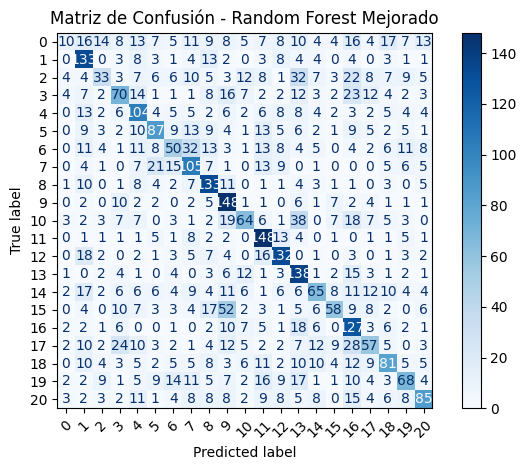


✅ Entrenamiento completado correctamente
📊 Accuracy (Train): 66.34%
📊 Accuracy (Test) : 45.66%
📉 Diferencia (Overfitting): 20.67%
📁 Modelo y métricas guardados en: ..\backend\models


In [23]:
# -----------------------------
# 7️⃣ Métricas y reportes
# -----------------------------
out_dir = Path("../backend/models")
out_dir.mkdir(parents=True, exist_ok=True)

report = classification_report(y_test, y_pred_test, digits=3, output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_df.to_csv(out_dir / "classification_report_rf_final.csv")

cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de Confusión - Random Forest Mejorado")
plt.tight_layout()
plt.savefig(out_dir / "confusion_matrix_rf_final.png")
plt.show()

# -----------------------------
# 8️⃣ Guardar modelo, PCA y scaler
# -----------------------------
model_path = out_dir / "random_forest_model_final.pkl"
with open(model_path, "wb") as f:
    pickle.dump(best_model, f)

with open(out_dir / "pca_scaler_final.pkl", "wb") as f:
    pickle.dump({"pca": pca, "scaler": scaler}, f)

print("\n==============================================================")
print("✅ Entrenamiento completado correctamente")
print(f"📊 Accuracy (Train): {train_acc*100:.2f}%")
print(f"📊 Accuracy (Test) : {test_acc*100:.2f}%")
print(f"📉 Diferencia (Overfitting): {diff:.2f}%")
print(f"📁 Modelo y métricas guardados en: {out_dir}")
print("==============================================================")